## 5.1 Identificação e descrição do problema
* **Título:** Detecção de E-mails de Phishing
* **Integrantes:** Danilo Campos Deichmann, Sidnei Silva Golçalves Junior, José Marcos Bittencourt Oliveira Prado
* **Fonte dos dados:** Kaggle (Phishing Email Dataset)
* **Objetivo:** Criar um modelo capaz de identificar e-mails maliciosos (phishing) para evitar o comprometimento de credenciais e sistemas corporativos.
* **Atributo-alvo:** `Email Type` (Safe Email / Phishing Email) -> Mapeado para `target_num` (0 e 1).
* **Atributos preditivos:** `Email Text` (Texto bruto da mensagem).
* **Tipo da tarefa:** Classificação binária.

## 5.2 Compreensão dos dados
O carregamento inicial revelou a presença de uma coluna inútil (`Unnamed: 0`) herdada do índice do CSV original, que foi removida.
A análise indica dados com alta incidência de duplicatas e alguns valores ausentes. A distribuição do atributo-alvo apresenta um desbalanceamento moderado, mas não severo, justificando atenção na fase de particionamento e na escolha das métricas (F1-Score em vez de apenas Acurácia).

In [15]:
import pandas as pd

df = pd.read_csv("https://github.com/DaniloCDD/Phishing-Detection/raw/refs/heads/main/Phishing_Email.zip", compression='zip')

print(df.columns.tolist())
display(df.head())

#df.panda é utilizado para remover linhas ou colunas
df = df.drop(columns=['Unnamed: 0'])

print("\n--- INFO DA BASE ---")
df.info()

print("\n--- VALORES NULOS ---")
print(df.isnull().sum())

print("\n--- DUPLICADOS ---")
print(df.duplicated().sum())

print("\n--- DISTRIBUIÇÃO DA CLASSE (%) ---")
print(df['Email Type'].value_counts(normalize=True) * 100)

df['tamanho_texto'] = df['Email Text'].astype(str).apply(len)
df['qtd_palavras'] = df['Email Text'].astype(str).apply(lambda x: len(x.split()))

print("\n--- ESTATÍSTICAS POR CLASSE ---")
display(df.groupby('Email Type')[['tamanho_texto', 'qtd_palavras']].describe())

['Unnamed: 0', 'Email Text', 'Email Type']


,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email



--- INFO DA BASE ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18650 entries, 0 to 18649
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Email Text  18634 non-null  object
 1   Email Type  18650 non-null  object
dtypes: object(2)
memory usage: 291.5+ KB

--- VALORES NULOS ---
Email Text    16
Email Type     0
dtype: int64

--- DUPLICADOS ---
1111

--- DISTRIBUIÇÃO DA CLASSE (%) ---
Email Type
Safe Email        60.707775
Phishing Email    39.292225
Name: proportion, dtype: float64

--- ESTATÍSTICAS POR CLASSE ---


tamanho_texto                                                 \
                       count         mean            std  min    25%    50%   
Email Type                                                                    
Phishing Email        7328.0  1610.407205    3349.373635  1.0  353.0  731.0   
Safe Email           11322.0  3493.008391  160168.024661  5.0  444.0  994.5   

                                    qtd_palavras                            \
                    75%         max        count        mean           std   
Email Type                                                                   
Phishing Email  1566.25    129635.0       7328.0  301.191184    569.722382   
Safe Email      2029.75  17036692.0      11322.0  685.870253  33160.236982   

                                                    
                min   25%    50%    75%        max  
Email Type                                          
Phishing Email  0.0  68.0  136.0  290.0    11625.0  
Safe Email      1.0  79.0  179.0  389.0  3527576.0

## 5.3 Análise exploratória
Foram gerados boxplots para analisar o comportamento estrutural das duas classes de e-mail. Observa-se que e-mails de Phishing tendem a ter uma distribuição diferente na quantidade de palavras e no tamanho do texto em comparação aos e-mails seguros, indicando que a estrutura textual será um fator discriminante útil para o algoritmo.

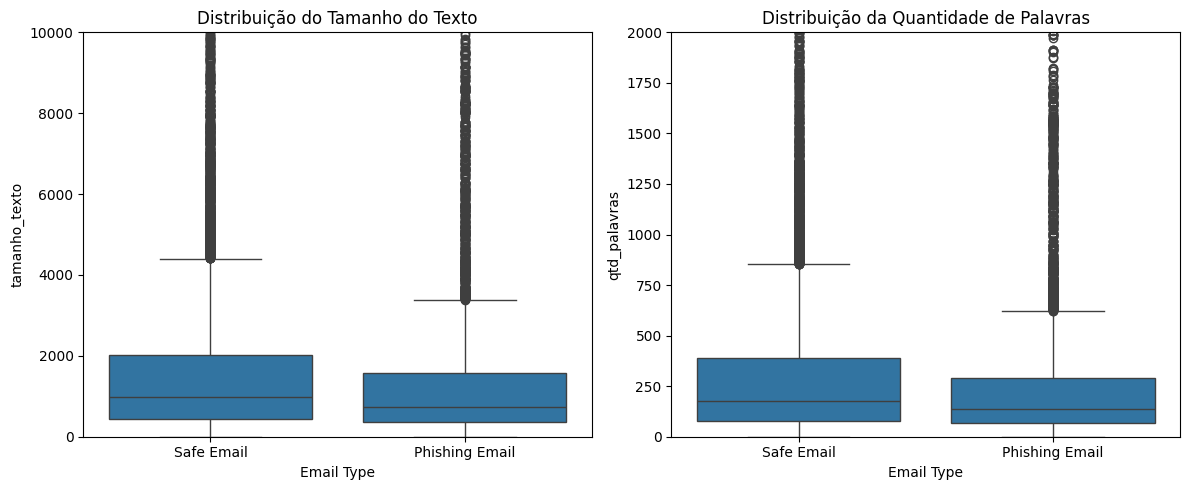

In [16]:
#import para os gráficos
import matplotlib.pyplot as plt
#suporte para o import acima
import seaborn as sns

#define o tamanho da tela
plt.figure(figsize=(12, 5))

#define o gráfico 1
plt.subplot(1, 2, 1)
sns.boxplot(x='Email Type', y='tamanho_texto', data=df)
plt.title('Distribuição do Tamanho do Texto')
plt.ylim(0, 10000)

#define o gráfico 2
plt.subplot(1, 2, 2)
sns.boxplot(x='Email Type', y='qtd_palavras', data=df)
plt.title('Distribuição da Quantidade de Palavras')
plt.ylim(0, 2000)

plt.tight_layout()
plt.show()

## 5.4 Pré-processamento
* **Valores ausentes e Inconsistências:** Linhas vazias na coluna de texto foram removidas via `dropna`.
* **Duplicações:** Registros com textos idênticos foram excluídos para impedir que o modelo "decore" mensagens repetidas, enviesando as métricas.
* **Variáveis categóricas:** O alvo foi binarizado (0 para Safe, 1 para Phishing).
* **Vazamento de dados (Data Leakage):** Para transformar o texto em números (Vetorização), a conversão definitiva via `TfidfVectorizer` foi encapsulada em um objeto `Pipeline` (detalhado na seção de avaliação). Isso garante que o vocabulário (TF-IDF) seja aprendido exclusivamente no conjunto de treino, prevenindo que informações da base de teste contaminem o algoritmo.

In [17]:
#apagar as linhas duplicadas, especificado na parte de texto do email
df = df.drop_duplicates(subset = ['Email Text'])

#apaga os erros do database, como textos vazios ou algo assim
df = df.dropna(subset=['Email Text'])

#mapeamento da variável alvo
df['target_num'] = df['Email Type'].map({'Safe Email': 0, 'Phishing Email': 1})

## 5.5 Separação dos dados
Os dados foram divididos na proporção clássica de 80% para treinamento e 20% para teste, garantindo volume suficiente para o aprendizado e uma amostra robusta para validação.
Utilizou-se o parâmetro `stratify=y` para garantir que a proporção exata de e-mails de phishing e e-mails seguros original seja mantida em ambos os conjuntos, prevenindo sub-representação de classes.

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Separando X (features/texto) e y (alvo numérico)
X = df['Email Text']
y = df['target_num']

# 2. Divisão em Treino (80%) e Teste (20%) com Estratificação
#x e y são os arrays, teste size é pra definir os 20%, random_state é pra deixar o numuro fixo para estar os 2 algoritmos com a mesma base de dados
#stratify é para deixar que a divisão do treino e do teste sejam iguals, não caia somente emails phishing ou so emails safe
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 67, stratify=y)

## 5.6 Modelagem
Foram testados dois modelos exigidos para tarefas de classificação: `SGDClassifier` e `RandomForestClassifier`.
Como baseline, ambos rodaram com parâmetros padrão usando uma vetorização prévia. O `SGDClassifier` demonstrou melhor custo-benefício computacional.
Em seguida, aplicou-se o `GridSearchCV` sobre o `SGD` para otimizar os parâmetros. A melhor configuração encontrada foi `loss='hinge'`, `penalty='l2'` e `alpha=0.0001`. A penalidade L2 com esse nível de alpha foi escolhida porque força a generalização, impedindo que o modelo decore palavras específicas do conjunto de treino (overfitting).

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.model_selection import GridSearchCV

tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Dimensões da matriz de treino: {X_train_tfidf.shape}")
print(f"Dimensões da matriz de teste: {X_test_tfidf.shape}\n")

rdf = RandomForestClassifier(random_state=67)
sgd = SGDClassifier(random_state=67)

rdf.fit(X_train_tfidf, y_train)
sgd.fit(X_train_tfidf, y_train)

y_pred_rdf = rdf.predict(X_test_tfidf)
y_pred_sgd = sgd.predict(X_test_tfidf)

print("--- BASELINE ---")
print(f"Matriz do RDF:\n{confusion_matrix(y_test, y_pred_rdf)}")
print(f"F1-Score RDF: {f1_score(y_test, y_pred_rdf):.4f}\n")

print(f"Matriz do SGD:\n{confusion_matrix(y_test, y_pred_sgd)}")
print(f"F1-Score SGD: {f1_score(y_test, y_pred_sgd):.4f}\n")

parametros_grid_1 = {
    'loss': ['hinge', 'log_loss'],
    'penalty': ['l2', 'l1', 'elasticnet'],
    'alpha': [1e-4, 1e-3, 1e-2],
    'max_iter': [1000, 2000]
}

grid_1 = GridSearchCV(SGDClassifier(random_state=67), parametros_grid_1, cv=5, scoring='f1', n_jobs=-1)
grid_1.fit(X_train_tfidf, y_train)

print("Grid Search procurando melhor parametro")
print(f"Melhores parâmetros: {grid_1.best_params_}")
print(f"Melhor F1-Score médio: {grid_1.best_score_:.4f}\n")

parametros_grid_2 = {
    'loss': ['hinge'],
    'penalty': ['l2'],
    'alpha': [1e-4, 1e-5, 1e-6],
    'max_iter': [1000]
}

grid_2 = GridSearchCV(SGDClassifier(random_state=67), parametros_grid_2, cv=5, scoring='f1', n_jobs=-1)
grid_2.fit(X_train_tfidf, y_train)

print("Grid Search best parametro")
print(f"Melhores parâmetros: {grid_2.best_params_}")
print(f"Melhor F1-Score médio: {grid_2.best_score_:.4f}")

## 5.7 Avaliação e discussão
O modelo de produção foi construído utilizando um `Pipeline` e avaliado no conjunto de teste isolado.

**Discussão dos resultados e Erros:**
A principal métrica de risco em detecção de phishing é a taxa de Falsos Positivos (bloquear e-mails legítimos). A Matriz de Confusão revelou um baixo número de falsos alarmes, confirmando a alta Precisão da classe 0. O F1-Score da classe 1 confirmou que a otimização parametrizada evitou o overfitting.

**Limitações e Melhorias:**
O modelo baseia-se puramente em TF-IDF (frequência de palavras). Limitações inerentes incluem a incapacidade de analisar contexto semântico profundo ou metadados de rede (IP do remetente, certificados de URL). Trabalhos futuros poderiam substituir a vetorização simples por embeddings de linguagem (como BERT) ou adicionar features extraídas da estrutura do cabeçalho do e-mail.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

pipeline_producao = Pipeline([
    ('vetorizador', TfidfVectorizer()),
    ('classificador', SGDClassifier(
        loss='hinge',
        penalty='l2',
        alpha=0.0001,
        max_iter=1000,
        random_state=67
    ))
])

pipeline_producao.fit(X_train, y_train)

y_pred = pipeline_producao.predict(X_test)

print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred))

print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred, digits=4))